# HO calving model of Luggye

We mesh Luggye glacier from its outline (the RGI outline intersected with our DEM), refined near the terminus digitized from imagery (DEM from 18 October 2025, terminus from 20 October). We invert for the bed by requiring the glacier to be in steady state with the DEM surface, then let the terminus evolve under a simple calving law. The HO approximation is used throughout.

## Imports and data

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import LineString, distance, points
import tqdm

from model import model
from bamg import bamg
from averaging import averaging
from issm_helper import *

data_dir = '/gpfs/home3/cbezu/issm/notebooks/data'
exp_file = data_dir + '/exp_files/DomainOutline_20260126_162319.exp'
dem_file = data_dir + '/dems/Luggye_2025_ds.tif'
thickness_file = data_dir + '/bed/thickness_RGI60-15.02373.tif'

could not import shapefile, PyShp has not been installed, no shapefile reading capabilities enabled


## Mesh

A 50 m mesh of the outline, refined to 20 m within about 50 m of the terminus.

In [2]:
terminus = LineString([ #copy/pasted from GEEDiT (longitude, latitude)
    (90.31877330330583, 28.09807611129586),
    (90.31919172791216, 28.098104504384743),
    (90.31958869484636, 28.0979909319842),
    (90.31985691574785, 28.09783950192981),
    (90.32003930596086, 28.097602892042097),
    (90.32007149246904, 28.097356817205473),
    (90.3201358654854, 28.097176992929565),
    (90.32029679802629, 28.096940381581167),
    (90.32055429009172, 28.09669430522543),
    (90.32076886681291, 28.096438763797273),
    (90.32100490120622, 28.096154828163456),
    (90.32110146073076, 28.095889820894154),
    (90.32110146073076, 28.095539631713223),
    (90.32101563004228, 28.095113724412702)
])
terminus = gpd.GeoSeries([terminus], crs = 'EPSG:4326').to_crs(epsg = 32645).iloc[0] #into the mesh's UTM 45N

md = bamg(model(), 'domain', exp_file, 'hmax', 50, 'hmin', 50)
d = distance(points(md.mesh.x, md.mesh.y), terminus) #distance from the terminus (m)
md = bamg(md, 'field', np.exp(-(d/50)**2), 'err', 1e-3, 'hmin', 20, 'hmax', 50)
x, y = md.mesh.x, md.mesh.y

At least one contour was not correctly oriented and has been re-oriented


## Data on the mesh

The DEM surface, the Farinotti bed (model 2) for comparison, and the ice level set: the signed distance to the terminus, negative on the ice.

In [3]:
s_0 = interpolate_raster(md, dem_file) #surface (m)
bed_farinotti = s_0 - interpolate_raster(md, thickness_file) #for comparison only
ice_levelset = terminus_levelset(md, terminus, surface = s_0)
ice = ice_levelset < 0

## Boundaries

Ice enters the domain through the two straight cuts across the glacier, along the top and east edges of the outline: there the velocity is free and the thickness is fixed. The velocity is zero on the rest of the boundary. ISSM only applies this where there is ice, so the lake edges need no special treatment.

In [4]:
boundary = md.mesh.vertexonboundary > 0
Γ_inflow = boundary & ((y > y.max() - 30) | (x > x.max() - 30)) #the top and east edges
Γ_sides = boundary & ~Γ_inflow

## Model parameters

Everything that is the same in every run. The lake is fresh water at 4500 m.

In [5]:
waterline = 4500 #lake level (m)

initialization_params = {'approximation': 'HO', 'vertical_layers': 5, 'temperature': 273.15, 'friction': 1e4,
                         'waterline': waterline, 'rho_water': 1000, 'ice_levelset': ice_levelset,
                         'spcvx': dirichlet(md, (Γ_sides, 0)), 'spcvy': dirichlet(md, (Γ_sides, 0))}

md.settings.solver_residue_threshold = 100

## Bed inversion

Following van Pelt et al. (2013): starting from a uniform 100 m of ice, run the model forward for a year from the DEM surface, with the front fixed. Then lower the bed where the surface rose and raise it where it fell, by a fraction K of the smoothed surface change. Stop when the misfit stops decreasing.

In [6]:
H_start = 100 #initial guess for the thickness (m)
K = 0.5 #bed correction per metre of surface misfit
Δt, num_steps = 0.2, 5 #one year per iteration
max_iterations = 50

bed = s_0 - H_start
misfits = []

for iteration in tqdm.trange(max_iterations):
    md_inv = initialize_model(copy.deepcopy(md), bed = bed, thickness = s_0 - bed, moving_front = False,
                              spcthickness = dirichlet(md, (Γ_inflow, s_0 - bed)), **initialization_params)
    u, H, s = coupled_solve(md_inv, Δt, num_steps = num_steps)

    misfit = averaging(md, s - s_0, 1).ravel() #smoothed surface change (m)
    misfit[~ice] = 0
    rms = np.sqrt(np.mean(misfit[ice]**2))
    if misfits and rms > misfits[-1]: #the misfit grew: keep the previous bed and stop
        bed = previous_bed
        break
    misfits.append(rms)
    previous_bed, bed = bed, bed - K*misfit

 50%|█████     | 25/50 [16:04<16:04, 38.59s/it]


## Inversion result

As a sanity check, the lake should be about 50 m deep at the terminus. The inverted bed is saved, since it takes a while to compute.

lake depth at the terminus: 68 m (expected: about 50 m)


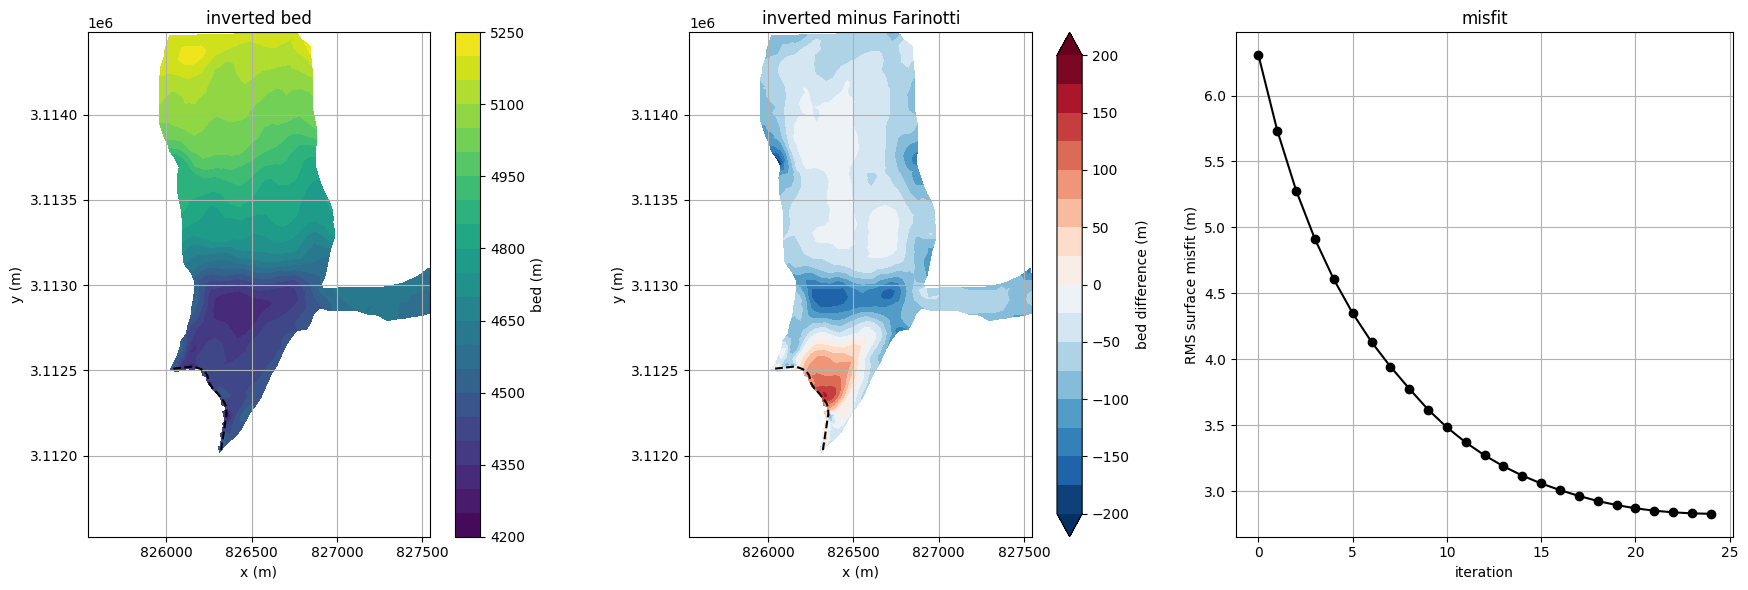

In [7]:
front = ice & (np.abs(ice_levelset) < 40) #ice within 40 m of the terminus
print(f'lake depth at the terminus: {np.median(waterline - bed[front]):.0f} m (expected: about 50 m)')
np.savez(data_dir + '/luggye_bed_inverted.npz', x = x, y = y, bed = bed)

fig, axes = plt.subplots(1, 3, figsize = (18, 6))
plot_field(md_inv, bed, ax = axes[0], label = 'bed (m)', title = 'inverted bed')
plot_field(md_inv, bed - bed_farinotti, ax = axes[1], label = 'bed difference (m)', title = 'inverted minus Farinotti',
           cmap = 'RdBu_r', levels = np.arange(-200, 201, 25), extend = 'both')
axes[2].plot(misfits, 'ko-')
axes[2].set(xlabel = 'iteration', ylabel = 'RMS surface misfit (m)', title = 'misfit')
axes[2].grid()
plt.tight_layout()
plt.show()

## Calving

From the inverted bed, the front now moves with the ice and retreats at a calving rate c·d, with H the ice thickness and d the water depth.

In [8]:
c = 0.5 #calving coefficient (a^-1)
Δt = 1 #time step (a)
model_time = 10 #a

md_calving = initialize_model(copy.deepcopy(md), bed = bed, thickness = s_0 - bed, moving_front = True,
                              spcthickness = dirichlet(md, (Γ_inflow, s_0 - bed)), **initialization_params)
H_0 = md_calving.geometry.thickness[:md.mesh.numberofvertices].copy() #initial thickness (m)

for step in tqdm.trange(int(model_time/Δt)):
    d = np.maximum(waterline - md_calving.geometry.base, 0) #water depth (m)
    rate = c*d #m/a
    rate_law(md_calving, rate = rate, extrapolate = True)
    u, H, s = coupled_solve(md_calving, Δt)

100%|██████████| 10/10 [01:20<00:00,  8.08s/it]


## Calving result

The dashed black line is the terminus after the run, the dotted red line the initial one. The thickness change is largest where the front has moved.

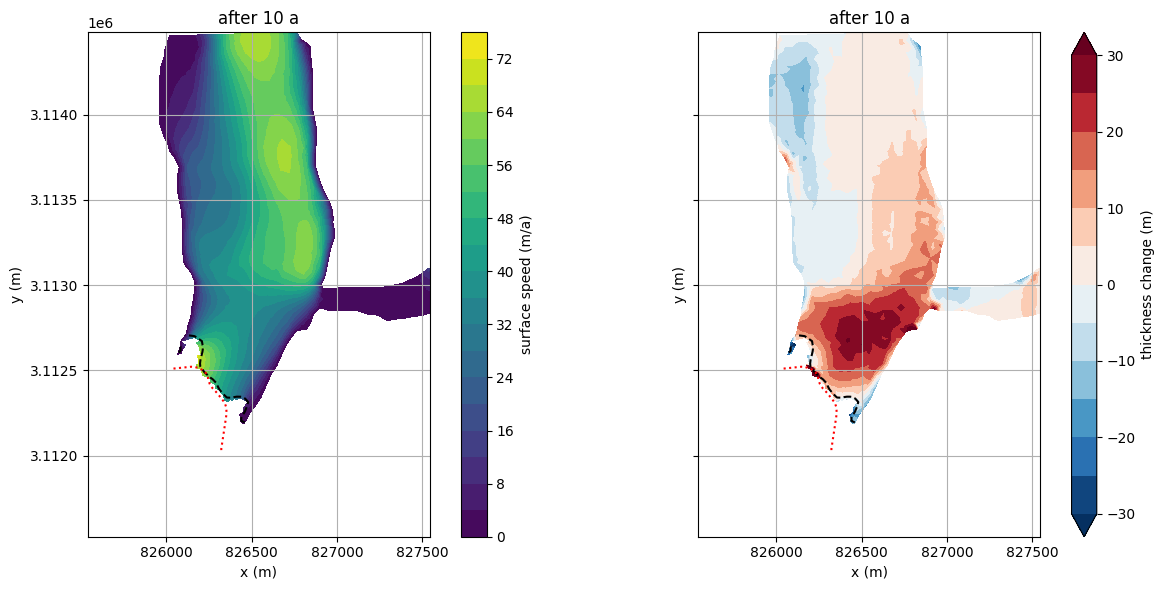

In [9]:
fig, axes = plt.subplots(1, 2, figsize = (13, 6), sharex = True, sharey = True)
plot_field(md_calving, np.hypot(u[0], u[1]), ax = axes[0], label = 'surface speed (m/a)', title = f'after {model_time} a')
plot_field(md_calving, H - H_0, ax = axes[1], label = 'thickness change (m)', title = f'after {model_time} a',
           cmap = 'RdBu_r', levels = np.arange(-30, 31, 5), extend = 'both')
for ax in axes:
    ax.tricontour(x, y, md.mesh.elements - 1, ice_levelset, levels = [0], colors = 'r', linestyles = 'dotted')
plt.tight_layout()
plt.show()